In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

In [3]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [5]:
# reading the dataset:
df = pd.read_csv('Salary_Data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [8]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [9]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

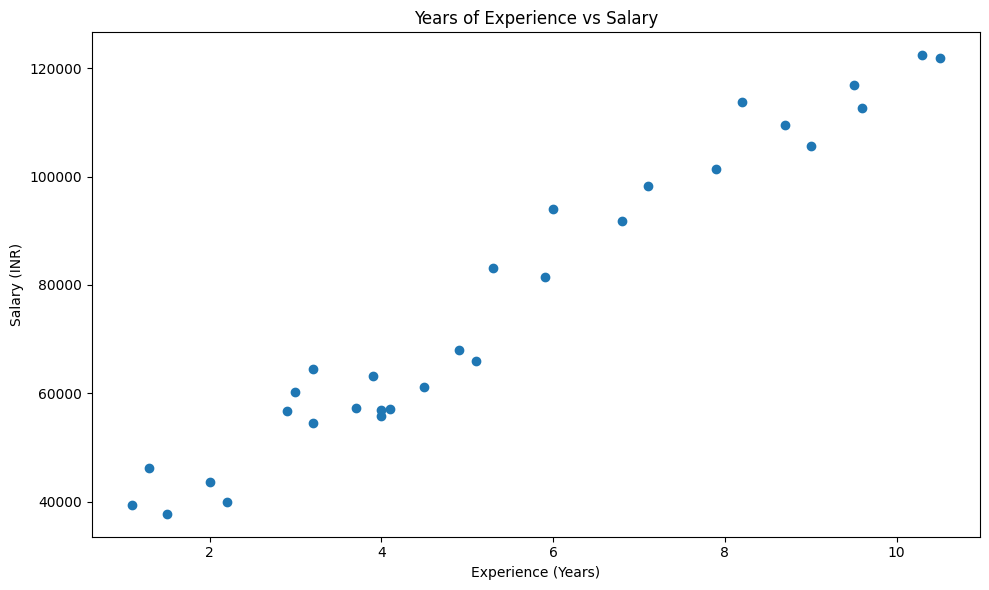

In [11]:
# exploring the given dataset with scatter plot:
plt.figure(figsize=(10,6))
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('Experience (Years)')
plt.ylabel('Salary (INR)')
plt.title('Years of Experience vs Salary')
plt.tight_layout()
plt.show()


In [13]:
X = df[['YearsExperience']]
y = df['Salary']

# checking the types of independent (X) and dependent (y) variables:
print(f"Type of X: {type(X)}")
print(f"Type of y: {type(y)}")

Type of X: <class 'pandas.core.frame.DataFrame'>
Type of y: <class 'pandas.core.series.Series'>


In [15]:
# train, test, and splitting the data:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# and checking the shape of extracted parts of data:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print()

(24, 1)
(6, 1)
(24,)
(6,)



In [19]:
# ==============Training the Linear Regression Model=======
# To import the required class
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# To train the model with training data
model.fit(X_train, y_train)

# And then getting the predictions for testing data :
y_pred = model.predict(X_test)
y_pred

# also combining actual and predicted output for testing data to compare:
result = pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
result

,Actual,Predicted
27,112635.0,115790.210113
15,67938.0,71498.278095
23,113812.0,102596.868661
17,83088.0,75267.804224
8,64445.0,55477.792045
9,57189.0,60189.699707


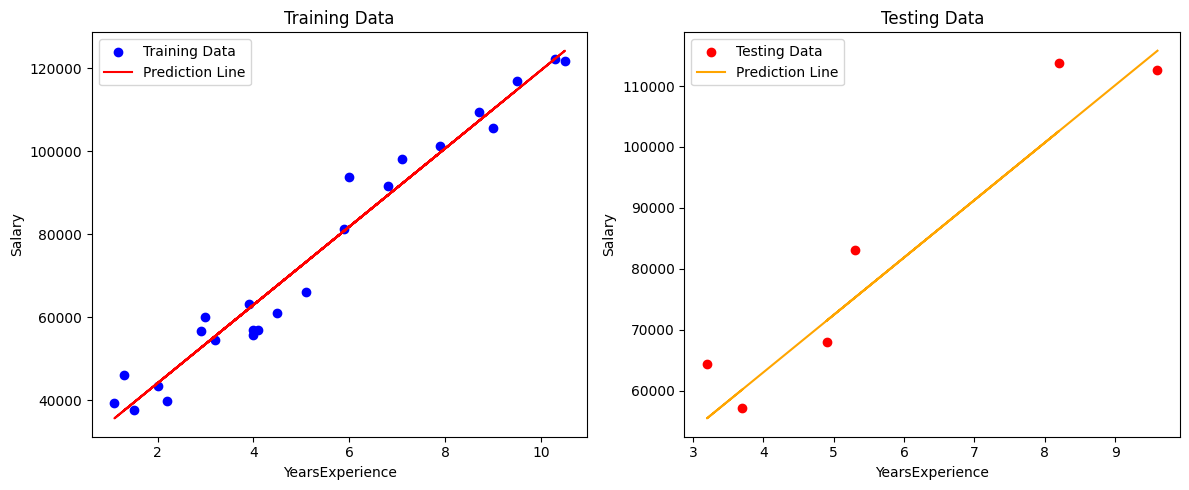

In [21]:
# Training and testing predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Set up subplots side by side
plt.figure(figsize=(12, 5))

# === Plot 1: Training Data ===
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.plot(X_train, y_train_pred, color='red', label='Prediction Line')
plt.title('Training Data')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.legend()

# === Plot 2: Testing Data ===
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color='red', label='Testing Data')
plt.plot(X_test, y_test_pred, color='orange', label='Prediction Line')
plt.title('Testing Data')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# analysing the parameters of linear regression model
coeff = model.coef_[0]
intercept = model.intercept_
print(f"The coefficient is : {coeff}")
print(f"The intercept is : {intercept}")

The coefficient is : 9423.815323030976
The intercept is : 25321.583011776813


In [23]:
# evaluating the performance of trained linear model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print(f"The R2 Score is : {r2_score(y_pred, y_test)}")
print(f"The Mean Squarred Value : {mean_squared_error(y_pred, y_test)}")
print(f"The Mean Absolute Error : {mean_absolute_error(y_pred, y_test)}")

The R2 Score is : 0.8961838737587328
The Mean Squarred Value : 49830096.85590839
The Mean Absolute Error : 6286.453830757749
